# Базовый блок. Архитектура автокодировщика (Autoencoder). ДЗ Ultra Pro

## Задание

Создайте автокодировщик, удаляющий чёрные квадраты в случайных областях изображений.

Алгоритм действий:
1. Возьмите базу картинок Mnist.
2. На картинках в случайных местах сделайте чёрные квадраты размера 8 на 8.
3. Создайте и обучите автокодировщик восстанавливать оригинальные изображения из «зашумлённых» квадратом изображений.
4. Добейтесь MSE < 0.0070 на тестовой выборке

## Импорт библиотек

In [ ]:
# Отображение
import matplotlib.pyplot as plt

# Для работы с тензорами
import numpy as np

# Класс создания модели
from tensorflow.keras.models import Model

# Для загрузки данных
from tensorflow.keras.datasets import mnist

# Необходимые слои
from tensorflow.keras.layers import Input, Conv2DTranspose, MaxPooling2D, Conv2D, BatchNormalization, Concatenate

# Оптимизатор
from tensorflow.keras.optimizers import Adam

%matplotlib inline

## Данные

In [ ]:
# Загрузка данных
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Нормировка данных
X_train = X_train.astype('float32')/255.
X_test = X_test.astype('float32')/255.

In [ ]:
# Изменение формы под удобную для Keras
X_train = X_train.reshape((-1, 28, 28, 1))
X_test = X_test.reshape((-1, 28, 28, 1))

### Создание зашумлённых данных - чёрные квадраты 8×8 в случайных местах

In [ ]:
def add_black_squares(images, square_size=8, seed=None):
    """Добавляет чёрный квадрат заданного размера в случайное место каждого изображения."""
    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()

    noisy = images.copy()
    h, w = images.shape[1], images.shape[2]

    # Случайные верхние левые углы квадратов
    max_y = h - square_size
    max_x = w - square_size
    ys = rng.integers(0, max_y + 1, size=len(images))
    xs = rng.integers(0, max_x + 1, size=len(images))

    # Зануляем соответствующие области
    for i, (y, x) in enumerate(zip(ys, xs)):
        noisy[i, y:y + square_size, x:x + square_size, :] = 0.0

    return noisy


# Зашумлённые версии. Тренировку — со случайным сидом каждую эпоху? Сделаем фиксированно один раз.
X_train_noisy = add_black_squares(X_train, square_size=8, seed=42)
X_test_noisy  = add_black_squares(X_test,  square_size=8, seed=7)

print('X_train_noisy:', X_train_noisy.shape)
print('X_test_noisy :', X_test_noisy.shape)

X_train_noisy: (60000, 28, 28, 1)
X_test_noisy : (10000, 28, 28, 1)


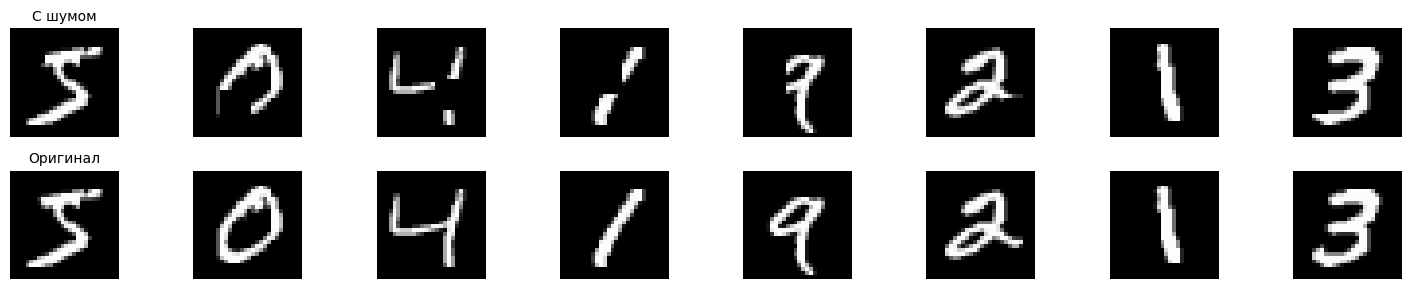

In [ ]:
# Посмотрим пары: «зашумлённое - оригинал»
plt.figure(figsize=(15, 3))
for i in range(8):
    plt.subplot(2, 8, i + 1)
    plt.imshow(X_train_noisy[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title('С шумом', fontsize=10)

    plt.subplot(2, 8, 8 + i + 1)
    plt.imshow(X_train[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title('Оригинал', fontsize=10)
plt.tight_layout()
plt.show()

### Архитектура автокодировщика

Используем U-Net-подобную архитектуру со **skip-connections**: результаты слоёв энкодера соединяем с соответствующими слоями декодера. Это критически важно для задач восстановления, потому что прокидывает в декодер высокочастотные детали изображения, не теряемые при downsampling.

In [ ]:
inp = Input(shape=(28, 28, 1))

#  Энкодер
e1 = Conv2D(32, (3, 3), padding='same', activation='relu')(inp)
e1 = BatchNormalization()(e1)
e1 = Conv2D(32, (3, 3), padding='same', activation='relu')(e1)
e1 = BatchNormalization()(e1)
p1 = MaxPooling2D((2, 2), padding='same')(e1)              # 14 x 14

e2 = Conv2D(64, (3, 3), padding='same', activation='relu')(p1)
e2 = BatchNormalization()(e2)
e2 = Conv2D(64, (3, 3), padding='same', activation='relu')(e2)
e2 = BatchNormalization()(e2)
p2 = MaxPooling2D((2, 2), padding='same')(e2)              # 7 x 7

#  Узкое место
b  = Conv2D(128, (3, 3), padding='same', activation='relu')(p2)
b  = BatchNormalization()(b)
b  = Conv2D(128, (3, 3), padding='same', activation='relu')(b)
b  = BatchNormalization()(b)

#  Декодер с skip-connections
u2 = Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='relu')(b)   # 14 x 14
u2 = Concatenate()([u2, e2])                                # skip с e2
d2 = Conv2D(64, (3, 3), padding='same', activation='relu')(u2)
d2 = BatchNormalization()(d2)
d2 = Conv2D(64, (3, 3), padding='same', activation='relu')(d2)
d2 = BatchNormalization()(d2)

u1 = Conv2DTranspose(32, (3, 3), strides=2, padding='same', activation='relu')(d2)  # 28 x 28
u1 = Concatenate()([u1, e1])                                # skip с e1
d1 = Conv2D(32, (3, 3), padding='same', activation='relu')(u1)
d1 = BatchNormalization()(d1)
d1 = Conv2D(32, (3, 3), padding='same', activation='relu')(d1)
d1 = BatchNormalization()(d1)

out = Conv2D(1, (3, 3), padding='same', activation='sigmoid')(d1)

autoencoder = Model(inp, out, name='denoising_autoencoder')
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 28, 28,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 28, 28,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 7, 7, 64)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 7, 7, 128) │     73,856 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 128) │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 7, 7, 128) │    147,584 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 128) │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 14, 14,    │     73,792 │ batch_normalizat… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 14, 14,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 519,969 (1.98 MB)

 Trainable params: 518,689 (1.98 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [ ]:
# Проверка размеров входа/выхода
print('Вход :', autoencoder.input_shape)
print('Выход:', autoencoder.output_shape)
assert autoencoder.input_shape == autoencoder.output_shape
print('Размеры совпадают ✓')

Вход : (None, 28, 28, 1)
Выход: (None, 28, 28, 1)
Размеры совпадают ✓


### Обучение

In [ ]:
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

history = autoencoder.fit(
    X_train_noisy, X_train,
    validation_data=(X_test_noisy, X_test),
    epochs=20,
    batch_size=128,
    shuffle=True,
    verbose=1
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - loss: 0.0108 - val_loss: 0.0175
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - loss: 0.0033 - val_loss: 0.0030
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - loss: 0.0024 - val_loss: 0.0028
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0020 - val_loss: 0.0022
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0018 - val_loss: 0.0023
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0017 - val_loss: 0.0022
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0017 - val_loss: 0.0023
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0016 - val_loss: 0.0022
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0015 - val_loss: 0.0022
Epoch 12/20
469/469 ━━━━━━━━━━

In [ ]:
# Оценка на тестовой выборке
test_loss = autoencoder.evaluate(X_test_noisy, X_test, verbose=0)
print(f'MSE на тестовой выборке: {test_loss:.5f}')
print(f'Цель < 0.0070: {"ДОСТИГНУТА ✓" if test_loss < 0.0070 else "НЕ ДОСТИГНУТА ✗"}')

MSE на тестовой выборке: 0.00224
Цель < 0.0070: ДОСТИГНУТА ✓


### Визуализация результатов

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


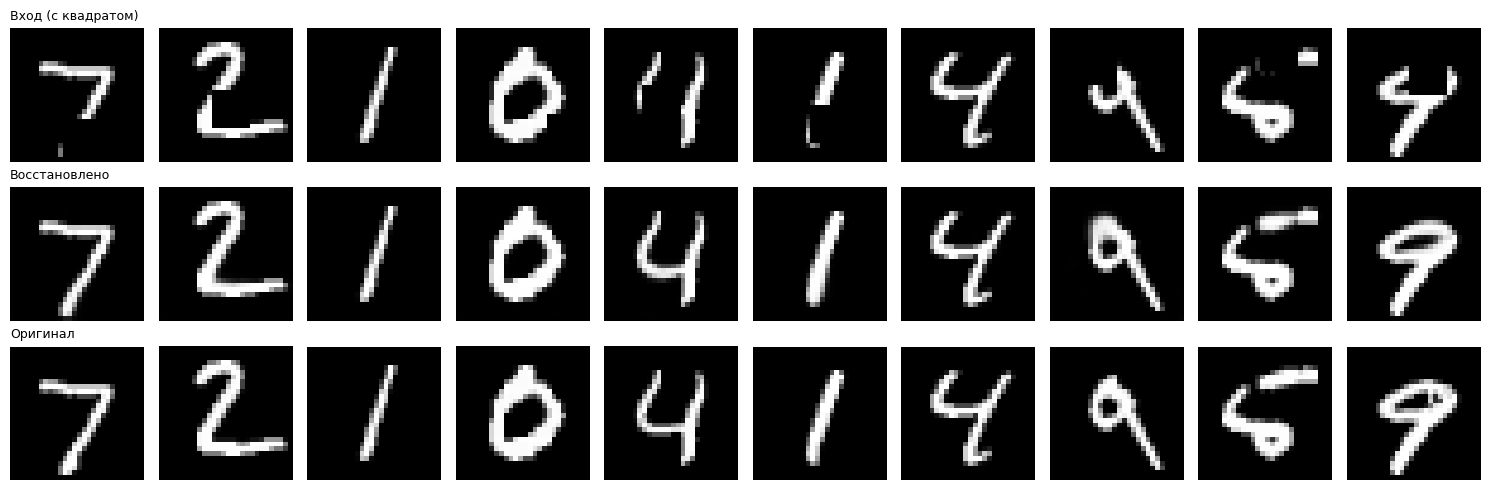

In [ ]:
# Прогоним зашумлённые тестовые картинки через автокодировщик
n = 10
preds = autoencoder.predict(X_test_noisy[:n])

plt.figure(figsize=(15, 5))
for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(X_test_noisy[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title('Вход (с квадратом)', fontsize=9, loc='left')

    plt.subplot(3, n, n + i + 1)
    plt.imshow(preds[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title('Восстановлено', fontsize=9, loc='left')

    plt.subplot(3, n, 2 * n + i + 1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title('Оригинал', fontsize=9, loc='left')

plt.tight_layout()
plt.show()

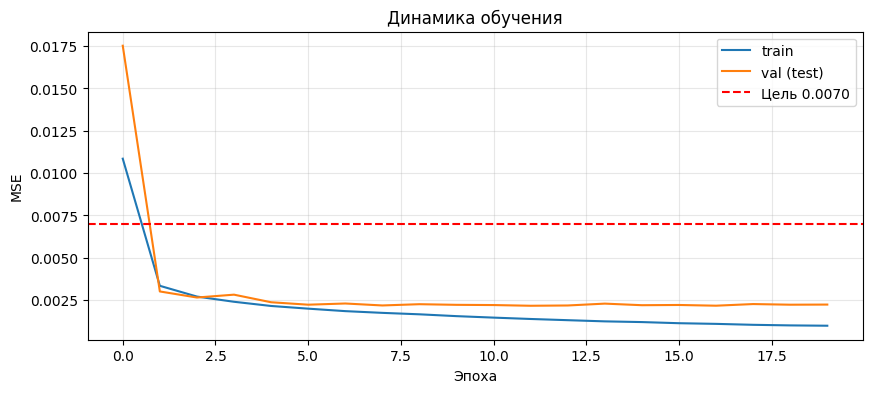

In [ ]:
# График обучения
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val (test)')
plt.axhline(0.0070, color='red', linestyle='--', label='Цель 0.0070')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Динамика обучения')
plt.show()